# Top interactors by interface metrics
Load every `results/<bait>__<prey>/interface_metrics.parquet`, rank preys, and merge with `data/pxd013906_uniprot_mapping.csv`.

In [56]:
from pathlib import Path
import pandas as pd

ROOT = Path("..") if Path("../results").exists() else Path(".")
RANK_METRIC = "ipsae"   # any of: ipsae, ilis, pinc, pdockq2, pair_iptm, ...
TOP_N = 15

In [57]:
files = sorted((ROOT / "results").glob("*/interface_metrics.parquet"))
metrics = pd.concat((pd.read_parquet(f) for f in files), ignore_index=True)
metrics[["bait", "prey"]] = metrics["pair"].str.split("__", n=1, expand=True)
print(len(files), "pairs;", len(metrics), "rows")
metrics.head()

1243 pairs; 1243 rows


,pair,seed,sample_index,cif_path,chain_i,chain_j,lis,clis,ilis,pinc,ipsae,pdockq,pdockq2,pair_iptm,note,bait,prey
0,A1L4W5__A0A1I9LLD2,1,0,A1L4W5__A0A1I9LLD2/raw/sample_0.cif,A,B,0.0,0.0,0.0,0.072391,0.0,0.0990,0.0086,0.110965,,A1L4W5,A0A1I9LLD2
1,A1L4W5__A0A1I9LMI7,1,0,A1L4W5__A0A1I9LMI7/raw/sample_0.cif,A,B,0.0,0.0,0.0,0.061235,0.0,0.0220,0.0081,0.095462,,A1L4W5,A0A1I9LMI7
2,A1L4W5__A0A1I9LPQ2,1,0,A1L4W5__A0A1I9LPQ2/raw/sample_0.cif,A,B,0.0,0.0,0.0,0.183183,0.0,0.0448,0.0103,0.106166,,A1L4W5,A0A1I9LPQ2
3,A1L4W5__A0A1I9LQ33,1,0,A1L4W5__A0A1I9LQ33/raw/sample_0.cif,A,B,0.0,0.0,0.0,0.097983,0.0,0.1747,0.0094,0.106143,,A1L4W5,A0A1I9LQ33
4,A1L4W5__A0A1I9LR66,1,0,A1L4W5__A0A1I9LR66/raw/sample_0.cif,A,B,0.0,0.0,0.0,0.072140,0.0,0.0347,0.0085,0.088038,,A1L4W5,A0A1I9LR66


## Rank preys
Per pair: best value of the ranking metric over diffusion samples and chain pairs. Then take the top N.

In [58]:
per_pair = (metrics.groupby(["pair", "bait", "prey"], as_index=False)
            .agg(best=(RANK_METRIC, "max"),
                 mean=(RANK_METRIC, "mean"),
                 n_rows=(RANK_METRIC, "size"),
                 ilis=("ilis", "max"), pinc=("pinc", "max"),
                 pdockq2=("pdockq2", "max"), pair_iptm=("pair_iptm", "max")))
top = per_pair.sort_values("best", ascending=False).head(TOP_N).reset_index(drop=True)
top

,pair,bait,prey,best,mean,n_rows,ilis,pinc,pdockq2,pair_iptm
0,A1L4W5__O22286,A1L4W5,O22286,0.725252,0.725252,1,0.572864,0.379806,0.0242,0.527265
1,A1L4W5__Q9SRV1,A1L4W5,Q9SRV1,0.724868,0.724868,1,0.583903,0.327081,0.0170,0.512343
2,A1L4W5__Q8L765,A1L4W5,Q8L765,0.721307,0.721307,1,0.603514,0.376467,0.0207,0.509467
3,A1L4W5__A1L4W5,A1L4W5,A1L4W5,0.694379,0.694379,1,0.574443,0.390971,0.0279,0.531382
4,A1L4W5__Q1EBV6,A1L4W5,Q1EBV6,0.690125,0.690125,1,0.602067,0.382738,0.0214,0.496102
5,A1L4W5__Q9M8J9,A1L4W5,Q9M8J9,0.676686,0.676686,1,0.581601,0.360380,0.0225,0.495598
6,A1L4W5__Q9LYA9,A1L4W5,Q9LYA9,0.540445,0.540445,1,0.420300,0.233519,0.0132,0.374568
7,A1L4W5__Q9SEU6,A1L4W5,Q9SEU6,0.526597,0.526597,1,0.576037,0.358660,0.0265,0.385439
8,A1L4W5__Q9SEU8,A1L4W5,Q9SEU8,0.502060,0.502060,1,0.546081,0.311987,0.0215,0.371722
9,A1L4W5__Q93ZE8,A1L4W5,Q93ZE8,0.462267,0.462267,1,0.400061,0.537281,0.0697,0.445629


## Merge with UniProt info table

In [59]:
info = pd.read_csv(ROOT / "data" / "pxd013906_uniprot_mapping.csv")
info = info.drop_duplicates("uniprot")   # one row per UniProt id
merged = top.merge(info, left_on="prey", right_on="uniprot", how="left")
print("unmatched preys:", merged["uniprot"].isna().sum())
merged

unmatched preys: 0


,pair,bait,prey,best,mean,n_rows,ilis,pinc,pdockq2,pair_iptm,...,uniprot,reviewed,genes,proteinDescription,length,organism,logfc,pval,adjp,annotation
0,A1L4W5__O22286,A1L4W5,O22286,0.725252,0.725252,1,0.572864,0.379806,0.0242,0.527265,...,O22286,True,BPM3,BTB/POZ and MATH domain-containing protein 3,408.0,Arabidopsis thaliana,5.392388,5.398775e-05,9.532030e-04,NaN
1,A1L4W5__Q9SRV1,A1L4W5,Q9SRV1,0.724868,0.724868,1,0.583903,0.327081,0.0170,0.512343,...,Q9SRV1,True,BPM4,BTB/POZ and MATH domain-containing protein 4,465.0,Arabidopsis thaliana,7.180554,3.989501e-12,2.519523e-10,BPM4
2,A1L4W5__Q8L765,A1L4W5,Q8L765,0.721307,0.721307,1,0.603514,0.376467,0.0207,0.509467,...,Q8L765,True,BPM1,BTB/POZ and MATH domain-containing protein 1,407.0,Arabidopsis thaliana,5.931116,3.277445e-06,7.914066e-05,BPM1
3,A1L4W5__A1L4W5,A1L4W5,A1L4W5,0.694379,0.694379,1,0.574443,0.390971,0.0279,0.531382,...,A1L4W5,True,BPM6,BTB/POZ and MATH domain-containing protein 6,415.0,Arabidopsis thaliana,8.563669,4.754271e-33,1.301085e-30,NaN
4,A1L4W5__Q1EBV6,A1L4W5,Q1EBV6,0.690125,0.690125,1,0.602067,0.382738,0.0214,0.496102,...,Q1EBV6,True,BPM5,BTB/POZ and MATH domain-containing protein 5,410.0,Arabidopsis thaliana,8.801948,6.753904e-22,7.393273e-20,BPM5
5,A1L4W5__Q9M8J9,A1L4W5,Q9M8J9,0.676686,0.676686,1,0.581601,0.360380,0.0225,0.495598,...,Q9M8J9,True,BPM2,BTB/POZ and MATH domain-containing protein 2,406.0,Arabidopsis thaliana,6.163266,6.283918e-07,1.778999e-05,BPM2
6,A1L4W5__Q9LYA9,A1L4W5,Q9LYA9,0.540445,0.540445,1,0.420300,0.233519,0.0132,0.374568,...,Q9LYA9,True,CSP41A,Chloroplast stem-loop binding protein of 41 kD...,406.0,Arabidopsis thaliana,5.587845,1.734651e-05,3.605438e-04,NaN
7,A1L4W5__Q9SEU6,A1L4W5,Q9SEU6,0.526597,0.526597,1,0.576037,0.358660,0.0265,0.385439,...,Q9SEU6,True,NaN,"Thioredoxin M4, chloroplastic",193.0,Arabidopsis thaliana,1.111247,4.506007e-01,4.748950e-01,NaN
8,A1L4W5__Q9SEU8,A1L4W5,Q9SEU8,0.502060,0.502060,1,0.546081,0.311987,0.0215,0.371722,...,Q9SEU8,True,TRXM2,"Thioredoxin M2, chloroplastic",186.0,Arabidopsis thaliana,1.111247,4.506007e-01,4.748950e-01,NaN
9,A1L4W5__Q93ZE8,A1L4W5,Q93ZE8,0.462267,0.462267,1,0.400061,0.537281,0.0697,0.445629,...,Q93ZE8,True,SDF2,Stromal cell-derived factor 2-like protein,218.0,Arabidopsis thaliana,1.150096,4.451117e-01,4.748950e-01,NaN


In [60]:
merged

,pair,bait,prey,best,mean,n_rows,ilis,pinc,pdockq2,pair_iptm,...,uniprot,reviewed,genes,proteinDescription,length,organism,logfc,pval,adjp,annotation
0,A1L4W5__O22286,A1L4W5,O22286,0.725252,0.725252,1,0.572864,0.379806,0.0242,0.527265,...,O22286,True,BPM3,BTB/POZ and MATH domain-containing protein 3,408.0,Arabidopsis thaliana,5.392388,5.398775e-05,9.532030e-04,NaN
1,A1L4W5__Q9SRV1,A1L4W5,Q9SRV1,0.724868,0.724868,1,0.583903,0.327081,0.0170,0.512343,...,Q9SRV1,True,BPM4,BTB/POZ and MATH domain-containing protein 4,465.0,Arabidopsis thaliana,7.180554,3.989501e-12,2.519523e-10,BPM4
2,A1L4W5__Q8L765,A1L4W5,Q8L765,0.721307,0.721307,1,0.603514,0.376467,0.0207,0.509467,...,Q8L765,True,BPM1,BTB/POZ and MATH domain-containing protein 1,407.0,Arabidopsis thaliana,5.931116,3.277445e-06,7.914066e-05,BPM1
3,A1L4W5__A1L4W5,A1L4W5,A1L4W5,0.694379,0.694379,1,0.574443,0.390971,0.0279,0.531382,...,A1L4W5,True,BPM6,BTB/POZ and MATH domain-containing protein 6,415.0,Arabidopsis thaliana,8.563669,4.754271e-33,1.301085e-30,NaN
4,A1L4W5__Q1EBV6,A1L4W5,Q1EBV6,0.690125,0.690125,1,0.602067,0.382738,0.0214,0.496102,...,Q1EBV6,True,BPM5,BTB/POZ and MATH domain-containing protein 5,410.0,Arabidopsis thaliana,8.801948,6.753904e-22,7.393273e-20,BPM5
5,A1L4W5__Q9M8J9,A1L4W5,Q9M8J9,0.676686,0.676686,1,0.581601,0.360380,0.0225,0.495598,...,Q9M8J9,True,BPM2,BTB/POZ and MATH domain-containing protein 2,406.0,Arabidopsis thaliana,6.163266,6.283918e-07,1.778999e-05,BPM2
6,A1L4W5__Q9LYA9,A1L4W5,Q9LYA9,0.540445,0.540445,1,0.420300,0.233519,0.0132,0.374568,...,Q9LYA9,True,CSP41A,Chloroplast stem-loop binding protein of 41 kD...,406.0,Arabidopsis thaliana,5.587845,1.734651e-05,3.605438e-04,NaN
7,A1L4W5__Q9SEU6,A1L4W5,Q9SEU6,0.526597,0.526597,1,0.576037,0.358660,0.0265,0.385439,...,Q9SEU6,True,NaN,"Thioredoxin M4, chloroplastic",193.0,Arabidopsis thaliana,1.111247,4.506007e-01,4.748950e-01,NaN
8,A1L4W5__Q9SEU8,A1L4W5,Q9SEU8,0.502060,0.502060,1,0.546081,0.311987,0.0215,0.371722,...,Q9SEU8,True,TRXM2,"Thioredoxin M2, chloroplastic",186.0,Arabidopsis thaliana,1.111247,4.506007e-01,4.748950e-01,NaN
9,A1L4W5__Q93ZE8,A1L4W5,Q93ZE8,0.462267,0.462267,1,0.400061,0.537281,0.0697,0.445629,...,Q93ZE8,True,SDF2,Stromal cell-derived factor 2-like protein,218.0,Arabidopsis thaliana,1.150096,4.451117e-01,4.748950e-01,NaN


## Consistently high across all metrics
Rank every pair on each metric (best value over samples/chain pairs, rank 1 = best), then keep the preys that are in the top `CONSISTENT_N` for **every** metric. `n_top` counts in how many metrics a prey makes the cut, so near-misses are visible too.

In [61]:
CONSISTENT_N = 50                                  # a prey must be in the top N of each metric
CONSISTENT_METRICS = ["ipsae", "ilis", "pinc", "pdockq2", "pair_iptm"]

best = metrics.groupby(["pair", "bait", "prey"], as_index=False)[CONSISTENT_METRICS].max()
ranks = best[CONSISTENT_METRICS].rank(ascending=False, method="min").astype(int)
ranks.columns = [f"rank_{m}" for m in CONSISTENT_METRICS]
cons = pd.concat([best, ranks], axis=1)
cons["n_top"] = (ranks <= CONSISTENT_N).sum(axis=1)
cons["worst_rank"] = ranks.max(axis=1)
cons["mean_rank"] = ranks.mean(axis=1).round(1)

cons = (cons.sort_values(["n_top", "mean_rank"], ascending=[False, True])
            .merge(info[["uniprot", "genes", "proteinDescription", "logfc", "adjp"]],
                   left_on="prey", right_on="uniprot", how="left")
            .drop(columns="uniprot"))

all_top = cons[cons["n_top"] == len(CONSISTENT_METRICS)]
print(f"{len(all_top)} prey(s) in the top {CONSISTENT_N} of all {len(CONSISTENT_METRICS)} metrics "
      f"(out of {len(cons)} pairs)")
cols = ["pair", "genes", "proteinDescription", "n_top", "worst_rank", "mean_rank"] \
       + [f"rank_{m}" for m in CONSISTENT_METRICS] + ["logfc", "adjp"]
cons[cols].head(max(TOP_N, len(all_top)))

21 prey(s) in the top 50 of all 5 metrics (out of 1243 pairs)


,pair,genes,proteinDescription,n_top,worst_rank,mean_rank,rank_ipsae,rank_ilis,rank_pinc,rank_pdockq2,rank_pair_iptm,logfc,adjp
0,A1L4W5__A1L4W5,BPM6,BTB/POZ and MATH domain-containing protein 6,5,9,5.6,4,6,9,8,1,8.563669,1.301085e-30
1,A1L4W5__Q93ZE8,SDF2,Stromal cell-derived factor 2-like protein,5,10,5.8,10,10,1,1,7,1.150096,4.748950e-01
2,A1L4W5__O22286,BPM3,BTB/POZ and MATH domain-containing protein 3,5,13,6.8,1,7,11,13,2,5.392388,9.532030e-04
3,A1L4W5__Q1EBV6,BPM5,BTB/POZ and MATH domain-containing protein 5,5,16,7.6,5,2,10,16,5,8.801948,7.393273e-20
4,A1L4W5__Q8L765,BPM1,BTB/POZ and MATH domain-containing protein 1,5,17,7.6,3,1,13,17,4,5.931116,7.914066e-05
5,A1L4W5__Q9M8J9,BPM2,BTB/POZ and MATH domain-containing protein 2,5,15,9.0,6,4,15,14,6,6.163266,1.778999e-05
6,A1L4W5__Q9SEU6,NaN,"Thioredoxin M4, chloroplastic",5,16,10.0,8,5,16,11,10,1.111247,4.748950e-01
7,A1L4W5__Q7EKM2,IRP5,NaN,5,14,10.4,13,14,7,9,9,3.224401,3.725629e-02
8,A1L4W5__Q39251,ADF2,Actin-depolymerizing factor 2,5,23,11.0,17,23,4,3,8,2.550351,2.685235e-01
9,A1L4W5__Q9SRV1,BPM4,BTB/POZ and MATH domain-containing protein 4,5,29,12.0,2,3,23,29,3,7.180554,2.519523e-10


## MYC interactors of interest
The MYC transcription factors (MYC2/3/4) are the curated jasmonate-signalling hits of the pulldown (`annotation` column of the UniProt table). Here is where each MYC pair lands in the global ranking, using the `cons` table above (rank 1 = best of all pairs), plus how many PLIP contacts the models carry.

In [62]:
MYC_PATTERN = r"^MYC"        # matched against the `annotation` column of the UniProt table

myc_ids = info.loc[info["annotation"].fillna("").str.contains(MYC_PATTERN), "uniprot"]
myc = cons[cons["prey"].isin(myc_ids)].copy()
myc = myc.merge(info[["uniprot", "annotation"]], left_on="prey", right_on="uniprot").drop(columns="uniprot")

def n_contacts(pair):
    f = ROOT / "results" / pair / "plip_summary.csv"
    return len(pd.read_csv(f)) if f.exists() else None
myc["n_plip"] = myc["pair"].map(n_contacts)

myc_cols = ["pair", "annotation", "n_top", "mean_rank"] + CONSISTENT_METRICS \
           + [f"rank_{m}" for m in CONSISTENT_METRICS] + ["n_plip", "logfc", "adjp"]
print(f"{len(myc)} MYC pair(s) out of {len(cons)} pairs")
myc[myc_cols].sort_values("mean_rank").reset_index(drop=True)

3 MYC pair(s) out of 1243 pairs


,pair,annotation,n_top,mean_rank,ipsae,ilis,pinc,pdockq2,pair_iptm,rank_ipsae,rank_ilis,rank_pinc,rank_pdockq2,rank_pair_iptm,n_plip,logfc,adjp
0,A1L4W5__Q9FIP9,MYC3,0,351.2,0.0,0.0,0.097853,0.0092,0.135385,174,146,544,478,414,32,6.339814,0.000009
1,A1L4W5__Q39204,MYC2,0,474.4,0.0,0.0,0.088881,0.0087,0.132950,174,146,658,958,436,26,5.941606,0.000157
2,A1L4W5__O49687,MYC4,0,605.6,0.0,0.0,0.068827,0.0087,0.112271,174,146,1033,958,717,37,6.339189,0.000003


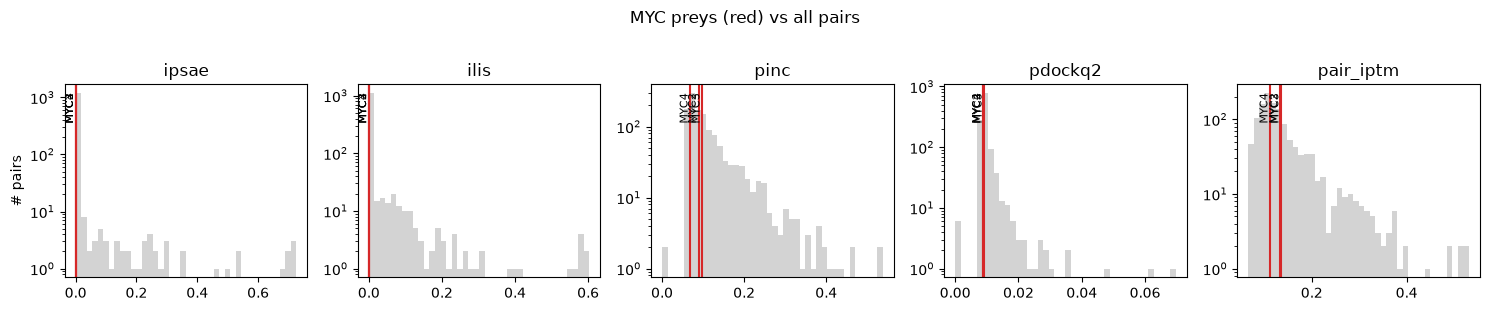

In [63]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(CONSISTENT_METRICS), figsize=(3 * len(CONSISTENT_METRICS), 3), sharey=False)
for ax, m in zip(axes, CONSISTENT_METRICS):
    ax.hist(cons[m], bins=40, color="lightgrey")
    for _, r in myc.iterrows():
        ax.axvline(r[m], color="tab:red", lw=1.5)
        ax.text(r[m], ax.get_ylim()[1] * 0.95, r["annotation"], rotation=90, va="top", ha="right", fontsize=8)
    ax.set_title(m)
    ax.set_yscale("log")
axes[0].set_ylabel("# pairs")
fig.suptitle("MYC preys (red) vs all pairs", y=1.02)
fig.tight_layout()

# Second run: Q9M548 vs nuclear E3 ligases and F-box proteins
Bait `Q9M548` against `results_q9m548_e3_fbox/`. Prey annotation comes from the UniProt retrievals `data/uniprot_retrieval/e3_nuclear.tsv` and `fbox_nuclear.tsv` (a prey can be in both lists, so we keep one row per entry and flag the source list).

In [64]:
RUN2 = ROOT / "results_q9m548_e3_fbox"
RETRIEVAL = ROOT / "data" / "uniprot_retrieval"

files2 = sorted(RUN2.glob("*/interface_metrics.parquet"))
metrics2 = pd.concat((pd.read_parquet(f) for f in files2), ignore_index=True)
metrics2[["bait", "prey"]] = metrics2["pair"].str.split("__", n=1, expand=True)
print(len(files2), "pairs;", len(metrics2), "rows")

466 pairs; 466 rows


## UniProt info for the run-2 preys

In [65]:
lists = []
for name in ["e3", "fbox"]:
    df = pd.read_csv(RETRIEVAL / f"{name}_nuclear.tsv", sep="\t")
    df["source"] = name
    lists.append(df)
info2 = pd.concat(lists, ignore_index=True)
info2 = (info2.groupby("Entry", as_index=False)
              .agg({"Gene Names": "first", "Protein names": "first",
                    "Subcellular location [CC]": "first",
                    "Gene Ontology (molecular function)": "first",
                    "InterPro": "first",
                    "source": lambda s: "+".join(sorted(set(s)))})
              .rename(columns={"Entry": "uniprot", "Gene Names": "genes", "Protein names": "proteinDescription",
                               "Subcellular location [CC]": "location", "Gene Ontology (molecular function)": "go_mf"}))
# first gene name as short label; strip ECO evidence tags from the location text
info2["gene"] = info2["genes"].fillna("").str.split().str[0]
info2["location"] = (info2["location"].fillna("").str.replace(r"\{[^}]*\}", "", regex=True)
                     .str.replace("SUBCELLULAR LOCATION: ", "", regex=False).str.replace(r"\s+", " ", regex=True).str.strip())
print(info2["source"].value_counts().to_string())
print("preys without info:", (~metrics2["prey"].drop_duplicates().isin(info2["uniprot"])).sum())

source
fbox       302
e3         249
e3+fbox      2
preys without info: 0


## Rank preys
Same scheme as run 1: best value over samples/chain pairs per metric, rank 1 = best, then count how many metrics place the prey in the top `CONSISTENT_N`.

In [66]:
best2 = metrics2.groupby(["pair", "bait", "prey"], as_index=False)[CONSISTENT_METRICS].max()
ranks2 = best2[CONSISTENT_METRICS].rank(ascending=False, method="min").astype(int)
ranks2.columns = [f"rank_{m}" for m in CONSISTENT_METRICS]
cons2 = pd.concat([best2, ranks2], axis=1)
cons2["n_top"] = (ranks2 <= CONSISTENT_N).sum(axis=1)
cons2["worst_rank"] = ranks2.max(axis=1)
cons2["mean_rank"] = ranks2.mean(axis=1).round(1)

cons2 = (cons2.sort_values(["n_top", "mean_rank"], ascending=[False, True])
              .merge(info2[["uniprot", "gene", "proteinDescription", "source", "location", "go_mf", "InterPro"]],
                     left_on="prey", right_on="uniprot", how="left")
              .drop(columns="uniprot"))

all_top2 = cons2[cons2["n_top"] == len(CONSISTENT_METRICS)]
print(f"{len(all_top2)} prey(s) in the top {CONSISTENT_N} of all {len(CONSISTENT_METRICS)} metrics "
      f"(out of {len(cons2)} pairs)")
cols2 = ["pair", "gene", "proteinDescription", "source", "n_top", "worst_rank", "mean_rank"] \
        + [f"rank_{m}" for m in CONSISTENT_METRICS]
cons2[cols2].head(max(TOP_N, len(all_top2)))

31 prey(s) in the top 50 of all 5 metrics (out of 466 pairs)


,pair,gene,proteinDescription,source,n_top,worst_rank,mean_rank,rank_ipsae,rank_ilis,rank_pinc,rank_pdockq2,rank_pair_iptm
0,Q9M548__Q84V15,At2g18780,F-box protein At2g18780,fbox,5,2,1.2,1,1,1,1,2
1,Q9M548__Q94B55,XBAT31,Putative E3 ubiquitin-protein ligase XBAT31 (E...,e3,5,4,2.4,2,2,4,3,1
2,Q9M548__Q9FLS0,At5g07610,F-box protein At5g07610,fbox,5,10,6.0,6,10,3,5,6
3,Q9M548__Q940T5,DURF2,E3 ubiquitin-protein ligase RDUF2 (EC 2.3.2.27...,e3,5,12,6.4,3,3,11,12,3
4,Q9M548__Q9SN27,ATL59,E3 ubiquitin-protein ligase ATL59 (EC 2.3.2.27...,e3,5,11,7.0,11,11,2,2,9
5,Q9M548__A0A1I9LT98,ATFDB20,F-box/kelch-repeat protein,fbox,5,20,8.2,4,4,20,9,4
6,Q9M548__O22283,RHC2A,Probable E3 ubiquitin-protein ligase RHC2A (EC...,e3,5,13,9.0,8,13,9,8,7
7,Q9M548__O23360,At4g15060,Putative F-box/LRR-repeat protein At4g15060,fbox,5,28,10.2,5,5,7,6,28
8,Q9M548__Q84RQ9,ARI12,Probable E3 ubiquitin-protein ligase ARI12 (EC...,e3,5,16,11.8,7,16,15,16,5
9,Q9M548__Q9M0U8,FBL21,Putative F-box/LRR-repeat protein 21,fbox,5,17,12.2,17,15,8,9,12


## Top preys: localisation and function
Subcellular location, molecular function (GO) and InterPro domains of the best-ranked preys.

In [67]:
cons2.head(TOP_N)[["prey", "gene", "source", RANK_METRIC, "location", "go_mf", "InterPro"]]

,prey,gene,source,ipsae,location,go_mf,InterPro
0,Q84V15,At2g18780,fbox,0.701423,,NaN,IPR006527;IPR017451;IPR036047;IPR001810;IPR011...
1,Q94B55,XBAT31,e3,0.576779,,ubiquitin protein ligase activity [GO:0061630],IPR002110;IPR036770;IPR056760;IPR001841;
2,Q9FLS0,At5g07610,fbox,0.367769,,NaN,IPR055290;IPR056592;IPR017451;IPR036047;IPR001...
3,Q940T5,DURF2,e3,0.526831,"Cytoplasm, cytosol .",ubiquitin protein ligase activity [GO:0061630]...,IPR010543;IPR039525;IPR001841;IPR013083;
4,Q9SN27,ATL59,e3,0.213421,Membrane ; Single-pass membrane protein .,ubiquitin protein ligase activity [GO:0061630]...,IPR053070;IPR001841;IPR013083;
5,A0A1I9LT98,ATFDB20,fbox,0.446742,,NaN,IPR050942;IPR001810;IPR005174;
6,O22283,RHC2A,e3,0.289720,,ubiquitin protein ligase activity [GO:0061630],IPR010543;IPR039525;IPR001841;IPR013083;
7,O23360,At4g15060,fbox,0.413550,,NaN,IPR036047;IPR053781;IPR001810;IPR050232;IPR032...
8,Q84RQ9,ARI12,e3,0.294672,,ubiquitin conjugating enzyme binding [GO:00316...,IPR031127;IPR002867;IPR044066;IPR013083;
9,Q9M0U8,FBL21,fbox,0.078343,,NaN,IPR036047;IPR001810;IPR032675;


## Metric distributions by prey family

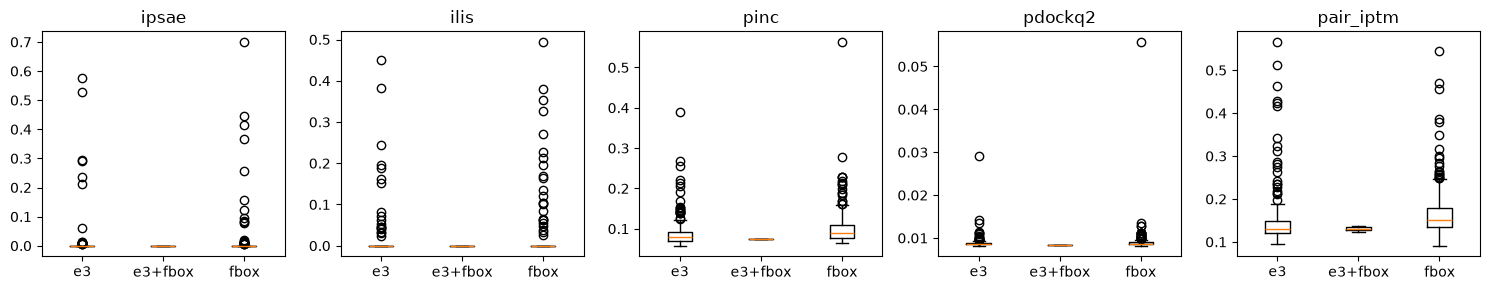

In [68]:
fig, axes = plt.subplots(1, len(CONSISTENT_METRICS), figsize=(3 * len(CONSISTENT_METRICS), 3))
for ax, m in zip(axes, CONSISTENT_METRICS):
    groups = [cons2.loc[cons2["source"] == s, m] for s in sorted(cons2["source"].dropna().unique())]
    ax.boxplot(groups)
    ax.set_xticklabels(sorted(cons2["source"].dropna().unique()))
    ax.set_title(m)
plt.tight_layout()

## CFK1 (known DRM2 interactor)
COP9 INTERACTING F-BOX KELCH 1 (CFK1, At1g23390, `Q9LDE3`) was found as a DRM2-interacting partner by yeast two-hybrid ([doi:10.1111/nph.17103](https://doi.org/10.1111/nph.17103)). Where does its pair land among the run-2 preys? Ties (e.g. ipsae = 0) share the lowest rank.

In [69]:
KNOWN = {"Q9LDE3": "CFK1"}   # UniProt id -> label; add other known interactors here

known = cons2[cons2["prey"].isin(KNOWN)].copy()
known.insert(0, "label", known["prey"].map(KNOWN))
print(f"{len(cons2)} pairs in run 2")
known[["label", "pair", "n_top", "worst_rank", "mean_rank"]
      + [f"rank_{m}" for m in CONSISTENT_METRICS] + CONSISTENT_METRICS]

466 pairs in run 2


,label,pair,n_top,worst_rank,mean_rank,rank_ipsae,rank_ilis,rank_pinc,rank_pdockq2,rank_pair_iptm,ipsae,ilis,pinc,pdockq2,pair_iptm
281,CFK1,Q9M548__Q9LDE3,2,404,181.8,48,43,249,404,165,0.0,0.0,0.083857,0.0084,0.156249


In [70]:
# per-sample / per-chain-pair rows: does any sample give a non-zero interface score?
metrics2[metrics2["prey"].isin(KNOWN)].sort_values(RANK_METRIC, ascending=False)

,pair,seed,sample_index,cif_path,chain_i,chain_j,lis,clis,ilis,pinc,ipsae,pdockq,pdockq2,pair_iptm,note,bait,prey
290,Q9M548__Q9LDE3,1,0,Q9M548__Q9LDE3/raw/sample_0.cif,A,B,0.0,0.0,0.0,0.083857,0.0,0.0804,0.0084,0.156249,,Q9M548,Q9LDE3


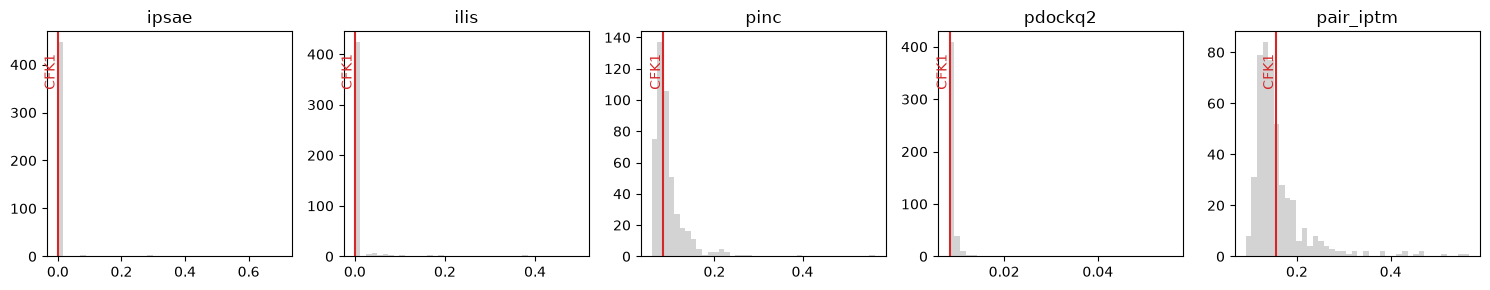

In [71]:
fig, axes = plt.subplots(1, len(CONSISTENT_METRICS), figsize=(3 * len(CONSISTENT_METRICS), 3))
for ax, m in zip(axes, CONSISTENT_METRICS):
    ax.hist(cons2[m], bins=40, color="lightgrey")
    for _, r in known.iterrows():
        ax.axvline(r[m], color="tab:red")
        ax.text(r[m], ax.get_ylim()[1] * 0.9, r["label"], color="tab:red", rotation=90, va="top", ha="right")
    ax.set_title(m)
plt.tight_layout()

### CFK1: PLIP contacts and contact heatmap
Number of PLIP contacts (rows of `plip_summary.csv`) for each run-2 pair, with the CFK1 pair highlighted, followed by the pre-computed PLIP contact heatmap.

CFK1: 80 PLIP contacts, rank 76/466 (median 55)
interaction_type
hydrogen_bonds              37
hydrophobic_interactions    30
salt_bridges                10
pi-stacking                  2
pi-cation_interactions       1


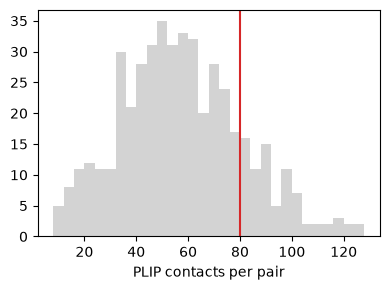

In [72]:
plip_n = pd.Series({f.parent.name: len(pd.read_csv(f)) for f in RUN2.glob("*/plip_summary.csv")}, name="n_contacts")
for prey, label in KNOWN.items():
    pair = f"Q9M548__{prey}"
    n = plip_n[pair]
    print(f"{label}: {n} PLIP contacts, rank {(plip_n > n).sum() + 1}/{len(plip_n)} (median {plip_n.median():.0f})")
    print(pd.read_csv(RUN2 / pair / "plip_summary.csv")["interaction_type"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(plip_n, bins=30, color="lightgrey")
for prey, label in KNOWN.items():
    ax.axvline(plip_n[f"Q9M548__{prey}"], color="tab:red")
ax.set_xlabel("PLIP contacts per pair")
plt.tight_layout()

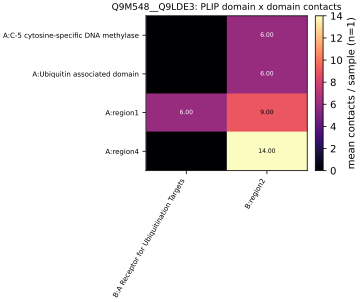

In [73]:
from IPython.display import SVG, display
for prey in KNOWN:
    display(SVG(filename=str(ROOT / "reports_q9m548_e3_fbox" / "folding" / f"Q9M548__{prey}" / "plip_contacts.svg")))